# Pré-processamento de Dados
## Tech Challenge Fase 1 — Saúde Feminina

Com base nos insights da EDA, este notebook realiza:
- Limpeza e encoding da variável alvo
- Remoção de features altamente correlacionadas (multicolinearidade)
- Análise de correlação com o target
- Split estratificado treino/teste
- Padronização das features (StandardScaler)
- Exportação dos dados processados para modelagem

## 1. Imports

In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings

sys.path.append('../src')
from preprocessing import load_data, encode_target, remove_high_correlation, split_data, scale_features

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 5)

## 2. Carregamento e limpeza inicial

In [2]:
df = load_data('../data/raw/data.csv')
print(f'Shape após remoção de colunas desnecessárias: {df.shape}')
print(f'Colunas removidas: id, Unnamed: 32')
df.head(3)

Shape após remoção de colunas desnecessárias: (569, 31)
Colunas removidas: id, Unnamed: 32


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


## 3. Encoding da variável alvo

Modelos de Machine Learning trabalham apenas com números. Convertemos:
- `B` (Benigno) → `0`
- `M` (Maligno) → `1`

In [3]:
df = encode_target(df)

print('Distribuição após encoding:')
print(df['diagnosis'].value_counts().rename({0: 'Benigno (0)', 1: 'Maligno (1)'}))

Distribuição após encoding:
diagnosis
Benigno (0)    357
Maligno (1)    212
Name: count, dtype: int64


## 4. Análise de multicolinearidade

Features altamente correlacionadas entre si carregam informação redundante e podem prejudicar alguns modelos. Removemos uma de cada par com correlação > 0.95.

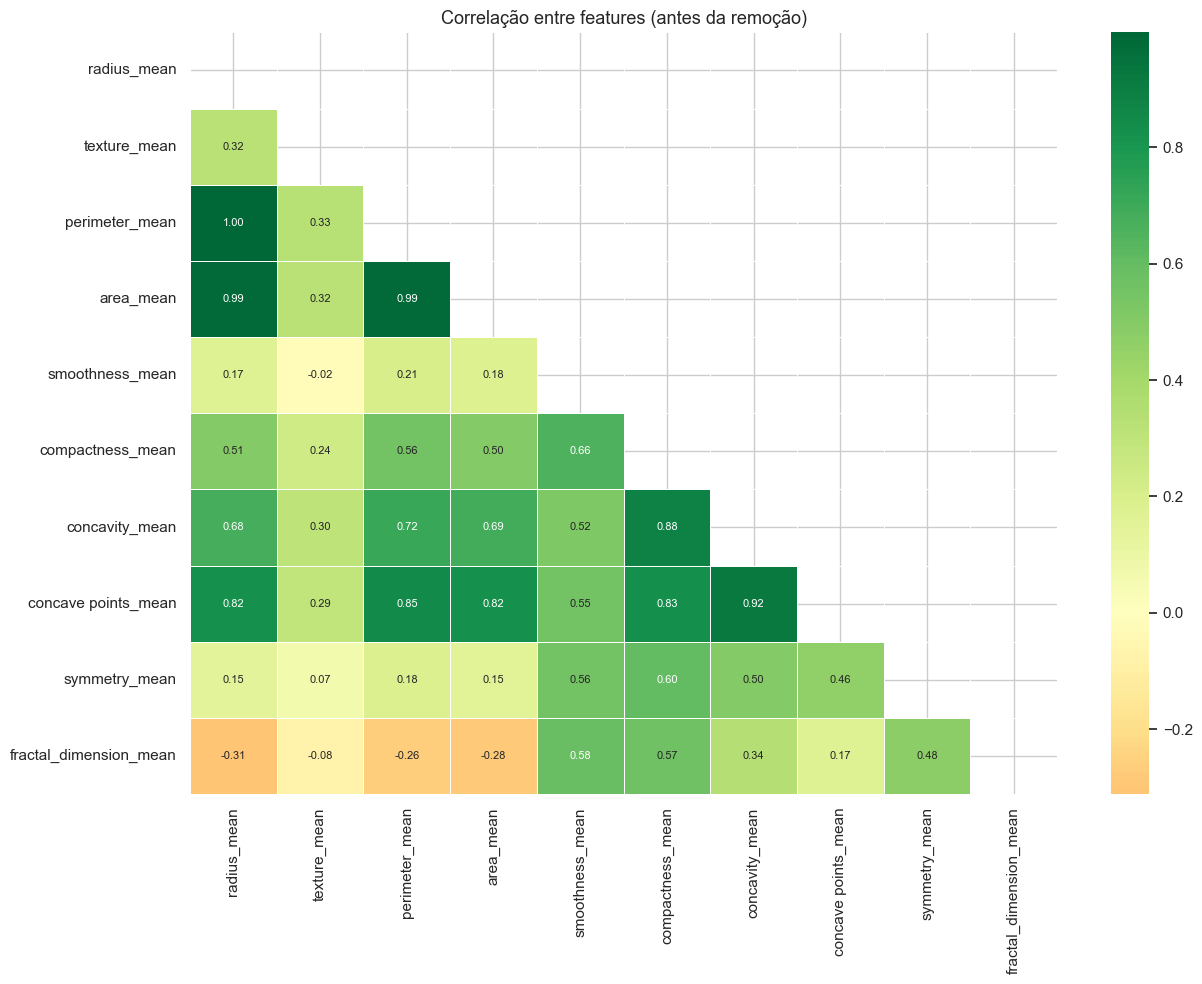

In [4]:
# Heatmap antes da remoção
features_mean = [c for c in df.columns if c.endswith('_mean')]

plt.figure(figsize=(13, 10))
corr_before = df[features_mean].corr()
mask = np.triu(np.ones_like(corr_before, dtype=bool))
sns.heatmap(corr_before, mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, linewidths=0.5, annot_kws={'size': 8})
plt.title('Correlação entre features (antes da remoção)', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/07_correlacao_antes.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
df_clean, dropped = remove_high_correlation(df, threshold=0.95)

print(f'Features removidas por alta correlação ({len(dropped)}): {dropped}')
print(f'\nShape antes : {df.shape}')
print(f'Shape depois: {df_clean.shape}')

Features removidas por alta correlação (7): ['perimeter_mean', 'area_mean', 'perimeter_se', 'area_se', 'radius_worst', 'perimeter_worst', 'area_worst']

Shape antes : (569, 31)
Shape depois: (569, 24)


## 5. Correlação das features restantes com o diagnóstico

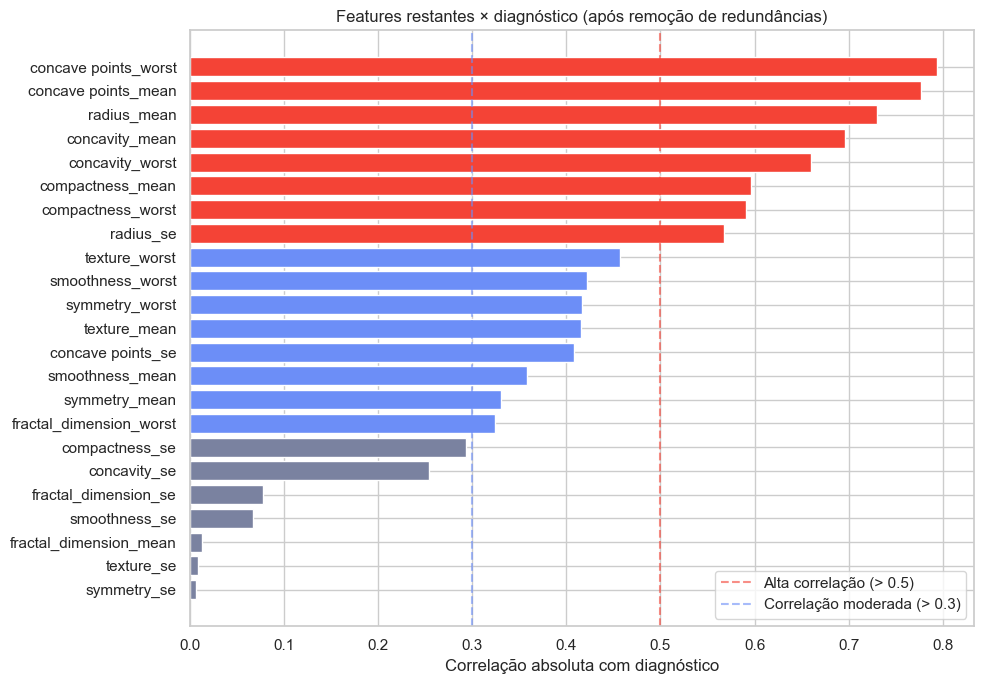


Top 10 features mais correlacionadas com diagnóstico maligno:
concave points_worst    0.793566
concave points_mean     0.776614
radius_mean             0.730029
concavity_mean          0.696360
concavity_worst         0.659610
compactness_mean        0.596534
compactness_worst       0.590998
radius_se               0.567134
texture_worst           0.456903
smoothness_worst        0.421465


In [6]:
corr_target = df_clean.corr()['diagnosis'].drop('diagnosis').abs().sort_values(ascending=False)

plt.figure(figsize=(10, 7))
colors = ['#F44336' if v >= 0.5 else '#6c8ef7' if v >= 0.3 else '#7a82a0'
          for v in corr_target.values]
plt.barh(corr_target.index[::-1], corr_target.values[::-1], color=colors[::-1])
plt.axvline(0.5, color='#F44336', linestyle='--', alpha=0.6, label='Alta correlação (> 0.5)')
plt.axvline(0.3, color='#6c8ef7', linestyle='--', alpha=0.6, label='Correlação moderada (> 0.3)')
plt.xlabel('Correlação absoluta com diagnóstico')
plt.title('Features restantes × diagnóstico (após remoção de redundâncias)')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/08_correlacao_final.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 10 features mais correlacionadas com diagnóstico maligno:')
print(corr_target.head(10).to_string())

## 6. Split treino / teste

Separamos os dados em:
- **80% treino** — o modelo aprende com esses dados
- **20% teste** — avaliamos o modelo com dados que ele nunca viu

O split é **estratificado**: mantemos a mesma proporção de malignos/benignos nos dois conjuntos.

In [7]:
X_train, X_test, y_train, y_test = split_data(df_clean)

print(f'Treino : {X_train.shape[0]} amostras  ({y_train.mean()*100:.1f}% malignos)')
print(f'Teste  : {X_test.shape[0]} amostras  ({y_test.mean()*100:.1f}% malignos)')
print(f'Features: {X_train.shape[1]}')

Treino : 455 amostras  (37.4% malignos)
Teste  : 114 amostras  (36.8% malignos)
Features: 23


## 7. Padronização (StandardScaler)

Features com escalas muito diferentes (ex: `area_mean` em centenas vs `smoothness_mean` em decimais) prejudicam modelos como Regressão Logística e KNN.

O StandardScaler transforma cada feature para média 0 e desvio padrão 1.

> **Importante:** o scaler é ajustado **somente no treino** e aplicado ao teste — para não vazar informação dos dados de teste para o modelo.

In [8]:
X_train_scaled, X_test_scaled, scaler = scale_features(X_train, X_test)

# Usa as 3 primeiras features disponíveis como exemplo (dinâmico)
sample_cols = X_train.columns[:3].tolist()

print('Antes da padronização (treino):')
print(X_train[sample_cols].describe().loc[['mean', 'std']].round(3))
print('\nApós a padronização (treino):')
print(X_train_scaled[sample_cols].describe().loc[['mean', 'std']].round(3))

Antes da padronização (treino):
      radius_mean  texture_mean  smoothness_mean
mean       14.166        19.418            0.096
std         3.579         4.291            0.014

Após a padronização (treino):
      radius_mean  texture_mean  smoothness_mean
mean       -0.000         0.000            0.000
std         1.001         1.001            1.001


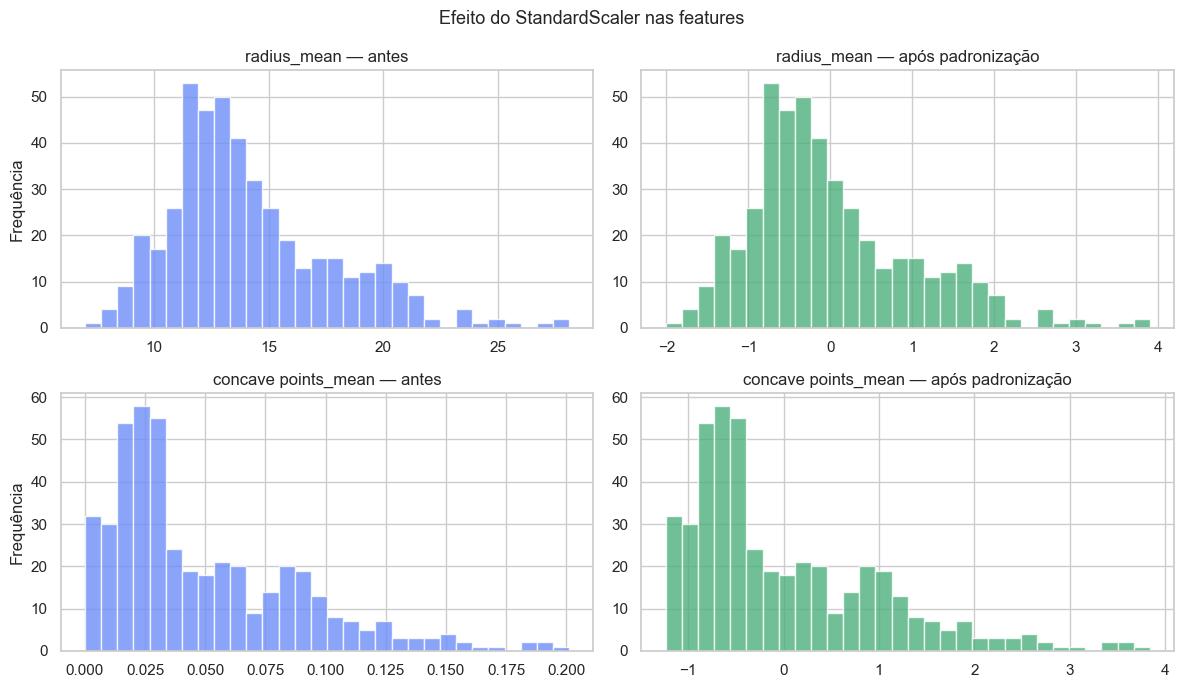

In [9]:
# Comparação visual antes x depois para duas features
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

for i, feat in enumerate(['radius_mean', 'concave points_mean']):
    axes[i][0].hist(X_train[feat], bins=30, color='#6c8ef7', edgecolor='white', alpha=0.8)
    axes[i][0].set_title(f'{feat} — antes')
    axes[i][0].set_ylabel('Frequência')

    axes[i][1].hist(X_train_scaled[feat], bins=30, color='#4caf7d', edgecolor='white', alpha=0.8)
    axes[i][1].set_title(f'{feat} — após padronização')

plt.suptitle('Efeito do StandardScaler nas features', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/09_padronizacao.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Exportação dos dados processados

In [10]:
X_train_scaled.to_csv('../data/processed/X_train.csv', index=False)
X_test_scaled.to_csv('../data/processed/X_test.csv',   index=False)
y_train.to_csv('../data/processed/y_train.csv', index=False)
y_test.to_csv('../data/processed/y_test.csv',   index=False)

joblib.dump(scaler, '../models/scaler.joblib')

print('Dados exportados para data/processed/')
print('Scaler salvo em models/scaler.joblib')

Dados exportados para data/processed/
Scaler salvo em models/scaler.joblib


## 9. Resumo do pré-processamento

| Etapa | Ação | Resultado |
|---|---|---|
| Remoção de colunas | `id`, `Unnamed: 32` removidos | Sem impacto nos modelos |
| Encoding | `B`→0, `M`→1 | Target numérico |
| Multicolinearidade | Features com correlação > 0.95 removidas | Redução de redundância |
| Split | 80% treino / 20% teste, estratificado | Proporção de classes preservada |
| Padronização | StandardScaler (fit no treino, transform no teste) | Features na mesma escala |

**Pipeline pronto.** Os dados em `data/processed/` estão prontos para alimentar os modelos no próximo notebook.